# **Convolution, Filtering and Correlation**


<div style="color:#777777;margin-top: -15px;">
<b>Author</b>: Norman Juchler |
<b>Course</b>: ADLS ISP |
<b>Version</b>: v1.4 <br><br>
<!-- 13.03.2025, v1.2: Fully refactored. -->
<!-- 06.03.2026, v1.3: Mildly refactored. -->
<!-- 18.03.2026, v1.4: Added illustration for reverberation. -->
</div>

In the lecture, we discussed how convolution is a fundamental operation in signal processing. But why is it so important? Let's explore its significance further in this exercise.

## **Exercises**
* [Exercise 1 – Filter a noisy signal](#exercise1)  
* [Exercise 2 – Explore the convolution](#exercise2)  
* [Exercise 3 – Impulse response](#exercise3)  
* [Exercise 4 - Auto-correlation](#exercise4)  

---

## **Preparations**

Let's begin with the usual preparatory steps...

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.fft import (fft, ifft, fftfreq, fftshift,
                       rfft, irfft, rfftfreq)
import soundfile as sf
import scipy.signal

# For audio playback
from IPython.display import Audio

# Jupyter / IPython configuration:
# Automatically reload modules when modified
%load_ext autoreload
%autoreload 2

# Enable vectorized output (for nicer plots)
%config InlineBackend.figure_formats = ["svg"]

import sys
sys.path.insert(0, "../")
import isp

Failed to read module file 'C:\Users\jmart\AppData\Local\Programs\Python\Python312\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\jmart\Documents\05_Studium\04_Programmierprojekte\04_Semester\ISP-Javier\venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jmart\Documents\05_Studium\04_Programmierprojekte\04_Semester\ISP-Javier\venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jmart\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<fr

---

<a id='exercise1'></a>

## **&#9734;  Exercise 1 – Filter a noisy signal**

In this exercise, we will address noise in a signal using a simple windowed average filter. This is done by convolving the discrete-time signal, $x[n]$, with a window function. A window function is defined as a function that is zero outside a specified interval and non-zero within that interval. When convolving a signal with a window function, we effectively average the signal over that interval.

This process is a form of **time-domain filtering**, where the signal is manipulated directly in the time domain using the windowed function. The window function is also referred to as the **kernel** of the filter.

### **Instructions**: 
* Read the audio signal from a file.
* Add noise to the signal.
* Choose a window function. You can find a list of available options [here](https://docs.scipy.org/doc/scipy/reference/signal.windows.html).
* Convolve the noisy signal with the window function.
* Visualize and compare the original signal, the noisy signal and the filtered signal
* Analyze the amplitude spectrum of:
  * (The original signal)
  * The noisy signal
  * The filtered signal
  * The window function itself
* Discuss the result:
  * Can you hear a difference between the original and filtered signals? If so, can you explain the reason?
  * Try different window functions. What differences do you observe?
  * How does changing the window width affect the results?


In [2]:
######################
###    EXCERISE    ###
######################

# 1) Load the audio file
audio_file = "../data/signals/fail.mp3"
x, sample_rate = isp.load_audio(audio_file, ensure1d=1)

# 2) Add noise to the signal
noise_std = 0.02    # Standard deviation of the noise
np.random.seed(0)   # Set seed for reproducibility
noise = np.random.normal(loc=0.0, 
                         scale=noise_std, 
                         size=x.shape)
x_noisy = x + noise

# 3) Create the window filter
width = 100
window = ...

# 4) Apply the filter to the noisy signal
x_filtered = ...

# 5) Listen to the results
display("Original")
display(Audio(x, rate=sample_rate))
display("Noisy")
display(Audio(x_noisy, rate=sample_rate))
display("Filtered")
display(Audio(x_filtered, rate=sample_rate))

# 6) Visualize the signals in the time domain
...   # Plot the original, noisy, and filtered signals in the time domain

# 7) Visualize the signals in the frequency domain
...   # Plot the amplitude spectrum of the original, noisy, and filtered signals


Failed to read module file 'c:\Users\jmart\Documents\05_Studium\04_Programmierprojekte\04_Semester\Image-and-Signal-Processing-FS26\notebooks\..\isp\fileio.py' for module 'isp.fileio': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\jmart\Documents\05_Studium\04_Programmierprojekte\04_Semester\ISP-Javier\venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "C:\Users\jmart\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 1855: character maps to <undefined>


'Original'

'Noisy'

'Filtered'

TypeError: float() argument must be a string or a real number, not 'ellipsis'

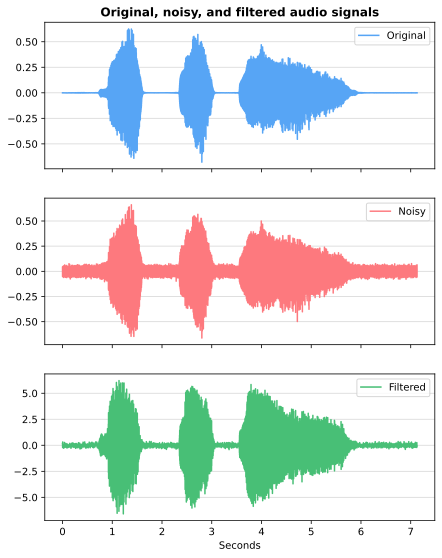

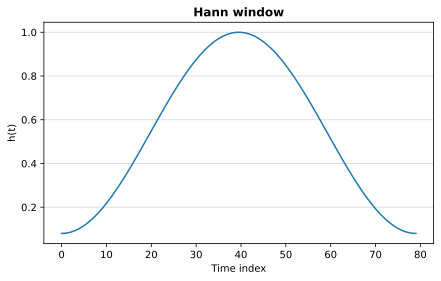

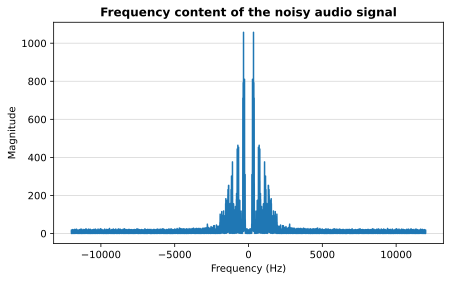

In [3]:
######################
###    SOLUTION    ###
######################

# 1) Load the audio file
audio_file = "../data/signals/fail.mp3"
x, sample_rate = isp.load_audio(audio_file, ensure1d=1)

# 2) Add noise to the audio signal
noise_std = 0.02    # Standard deviation of the noise
np.random.seed(0)   # Set seed for reproducibility
# Generate the noise (zero-mean Gaussian noise)
noise = np.random.normal(loc=0.0,
                         scale=noise_std, 
                         size=x.shape)
x_noisy = x + noise  # Add the generated noise

# 3+4) Apply a windowed filter to the noisy audio signal
#      Have a look at the different windows here:
#      https://docs.scipy.org/doc/scipy/reference/signal.windows.html
width = 80  # Window length in samples
w = scipy.signal.windows.chebwin(width, at=1000)
w = scipy.signal.windows.hann(width)
w = scipy.signal.windows.hamming(width)

# Apply the windowed filter
x_filtered = scipy.signal.convolve(x_noisy, w, mode="same")

# 5) Listen to the audio signals
display(Audio(x, rate=sample_rate),)            # Original
display(Audio(x_noisy, rate=sample_rate))       # Noisy
display(Audio(x_filtered, rate=sample_rate))    # Filtered

# 6+7) Time and frequency domain visualization

# Plot the audio signals in the time domain
fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
t = np.arange(x.size) / sample_rate  # Time vector
colors = isp.PALETTE
axes[0].plot(t, x, color=colors[0], label="Original")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.5)
axes[0].set_title("Original, noisy, and filtered audio signals", weight="bold")
axes[1].plot(t, x_noisy, color=colors[1], label="Noisy")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.5)
axes[2].plot(t, x_filtered, color=colors[2], label="Filtered")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.5)
plt.xlabel("Seconds")

# Visualize the filter window
plt.figure(figsize=(7, 4))
plt.plot(w)
plt.grid(axis="y", alpha=0.5)
plt.ylabel("h(t)")
plt.xlabel("Time index")
plt.title("Hann window", weight="bold")

# Visualize the frequency content of the noisy audio signal
# Compute the Fourier transform of the noisy audio signal
X_noisy = fft(x_noisy)
# Compute the frequency vector
f = fftfreq(x_noisy.size, 1 / sample_rate)
# Shift the frequency vector
f = fftshift(f)
# Shift the Fourier transform
X_noisy = fftshift(X_noisy)
# Plot the magnitude of the Fourier transform
plt.figure(figsize=(7, 4))
plt.plot(f, np.abs(X_noisy))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(axis="y", alpha=0.5)
plt.title("Frequency content of the noisy audio signal", weight="bold");

---

<a id='exercise2'></a>

## **&#9734; Exercise 2 – Explore the convolution**

In this exercise, we compare different methods for computing the convolution of two signals in Python. First, recall the definition of the convolution for discrete-time signals:

$$ y[n] = \sum_{k=0}^{K-1} h[k] \cdot x[n-k]$$

where $x$ is a signal with $N$ samples, and $h$ is a filter (or kernel) of length $K$. For a deeper explanation of convolution, see [this section](https://brianmcfee.net/dstbook-site/content/ch03-convolution/Convolution.html#) of Brian McFee’s excellent online book on **Digital Signal Theory**. 

We will explore four different approaches to implementing convolution and compare their results and execution times:

- **Method 1:** Implement the convolution manually using a **for-loop** (as shown in the lecture slides).  
- **Method 2:** Use NumPy’s built-in function [`np.convolve()`](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html).  
- **Method 3:** Use SciPy’s function [`scipy.signal.convolve()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html).  
- **Method 4:** Implement convolution using the **Fourier Transform** and the **convolution theorem**.

Compare the results produced by the four methods and measure the execution time of each implementation. Which method is the fastest, and why?

### **Instructions:**
* Implement all four methods.
* Run the prepared comparison code and analyze the results.  

**Hint:** When using `np.convolve()` and `scipy.signal.convolve()`, set the mode to "full" to obtain the complete convolution output.  





In [ ]:
######################
###    EXERCISE    ###
######################

# Create a simple signal (white noise)
N = int(1e4)
x = np.random.randn(N)

# Create a simple filter
K = 1000
h = scipy.signal.windows.hann(K)

def method1(h, x):
    """Method 1: Use a for loop"""    
    y = ...
    return y

def method2(h, x):
    """Method 2: Use np.convolve()"""
    y = ...
    return y

def method3(h, x):
    """Method 3: Use scipy.signal.convolve()"""
    y = ...
    return y

def method4(h, x):
    """Method 4: Use FFT and the convolution theorem"""
    y = ...
    return y


# Compare the different methods
import time
methods = [method1, method2, method3, method4]
method_names = ["for loop", "np.convolve", "scipy.signal.convolve", "FFT"]
timings = []
y_ref = scipy.signal.convolve(x, h, mode="full")
y_rets = []
for method, method_name in zip(methods, method_names):
    print(f"Running: {method_name}")
    tic = time.time()
    #timing = %timeit -o method(h, x)
    y = method(h, x)
    y_rets.append(y)
    toc = time.time()
    timings.append(toc-tic)
    plt.plot(y, label=method_name)

plt.plot(y_ref, "k:")
plt.legend()
plt.show()

print("Timings:")
for method, timing in zip(method_names, timings):
    print("%-25s %.3fms" % (method, timing*1000))

In [ ]:
######################
###    SOLUTION    ###
######################

# Create a simple signal (white noise)
N = int(1e4)
x = np.random.randn(N)

# Create a simple filter
K = 1000
h = scipy.signal.windows.hann(K)

def method1(h, x):
    """Method 1: Convolution using a for-loop"""
    y = np.zeros(x.size)
    for n in range(x.size):
        # For all elements of the input signal...
        for k in range(h.size):
            # ... compute the convolution
            if n >= k:
                # No contribution from samples n < k
                # (we cannot evaluate x[n-k] for n < k)
                y[n] += h[k] * x[n - k]
    return y

def method2(h, x):
    """Method 2: Using np.convolve"""
    y = np.convolve(x, h, mode="full")
    return y

def method3(h, x):
    """Method 3: Using scipy.signal.convolve"""
    y = scipy.signal.convolve(x, h, mode="full")
    return y

def method4(h, x):
    """Method 4: Using FFT and the convolution theorem"""
    # The following lines are necessary to mimic mode="full":
    #   – Zero‑padding for correct boundary handling (<-> mode="full")
    #   - Choose efficient FFT size via next_fast_len
    from scipy.fft import next_fast_len
    n_conv = x.size + h.size - 1   # Minimum correct output length
    n_fft = next_fast_len(n_conv)  # Round up to the nearest fast FFT size
    
    # Compute the FFT of the input signal
    X = fft(x, n=n_fft)
    # Compute the FFT of the filter window
    H = fft(h, n=n_fft)
    # Multiply the FFT of the input signal and the FFT of the filter window
    Y = X * H
    # Compute the inverse FFT of the product
    y = ifft(Y)
    # The result of the inverse FFT may still contain small 
    # imaginary parts due to numerical errors. Let's erase them.
    y = np.real_if_close(y, tol=1e-3)
    # Issue a warning if the result is still complex (which should not happen)
    if np.iscomplexobj(y):
        print("Warning: The result of the convolution is still complex!")
    return y[:n_conv]

# Compare the different methods
import time
methods = [method1, method2, method3, method4]
method_names = ["Method 1: for-loop", 
                "Method 2: np.convolve()", 
                "Method 3: scipy.signal.convolve()", 
                "Method 4: FFT (mode=full)"]


timings = []
max_errors = []
y_ref = scipy.signal.convolve(x, h, mode="full")
y_rets = []
for method, method_name in zip(methods, method_names):
    print(f"Running {method_name}")
    tic = time.time()
    y = method(h, x)
    toc = time.time()
    y_rets.append(y)
    
    # Bookkeeping
    timing = toc - tic
    timings.append(timing)
    max_error = np.max(np.abs(y-y_ref[:len(y)]))
    max_errors.append(max_error)
    plt.plot(y, label=method_name)

isp.show_header("Timings:", align="left")
for method, timing in zip(method_names, timings):
    print("   %-35s %8.3fms" % (method, timing*1000))
    
isp.show_header("Errors:", align="left")
for method, max_error in zip(method_names, max_errors):
    print("   %-35s %g" % (method, max_error))

plt.plot(y_ref, "k:")
plt.grid(axis="y", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

### **Discussion**

Exemplary timing results:

```lang-none
   Method 1: for loop                  2215.081ms
   Method 2: np.convolve()                4.034ms
   Method 3: scipy.signal.convolve()      0.196ms
   Method 4: FFT (naive)                  0.187ms
```

This exercise illustrates the performance benefit of using the FFT for convolution. FFT‑based methods are dramatically faster than time‑domain approaches, especially for large signals and filters. The key idea is that convolution in the time domain becomes simple elementwise multiplication in the frequency domain. After transforming both the signal and the filter using the FFT, multiplying them, and transforming the result back with the IFFT, the overall computational cost is lower than performing convolution directly. Because both the FFT and IFFT are highly optimized, this detour through the frequency domain becomes advantageous for longer inputs.

* Method 1: The for loop is by far the slowest approach, as pure Python is not optimized for numerical or vectorized computations.
* Method 2: In contrast, `np.convolve()` uses vectorized operations and internal optimizations, but it still performs the computation in the time domain.
* Method 3: `scipy.signal.convolve()` is typically the fastest method because it uses FFT-based convolution.
* Method 4: This method demonstrates how we can implement our own FFT-based convolution (with the same boundary handling as as `np.convolve()` and `scipy.signal.convolve()`)

---

<a id='exercise3'></a>

## **&#9734; Exercise 3 – Impulse response**

Let's recall the **impulse function**, which we encountered in the lecture. It is a function that is zero everywhere except at $t=0$, where it has a value such that its integral equals one. For **discrete-time signals**, the impulse function is defined as

$$
\delta[n]= [1, 0, 0, 0, \dots]
$$

If we use $x[n] = \delta[n]$ in a convolution operation, we obtain:  

$$
\begin{align*}
y[n] &= \sum_{k=0}^{K-1} h[k] \cdot x[n-k] \\
     &= h[n] \cdot \delta[0] \\
     &= h[n]
\end{align*}
$$

In simple terms: when we apply an impulse signal $\delta(t)$ to a filter or system $h(t)$ (or its discrete-time counterpart $h[n]$), the output is exactly $h(t)$ itself! This function $h(t)$ is called the **impulse response** of the system. The impulse response completely characterizes a convolutional system—no additional information is required.

If we want to understand how an *<u>unknown</u>* system transforms an input signal $x(t)$, we can measure the system's impulse response $h(t)$ and then compute the output by convolving $x(t)$ with $h(t)$.

In this exercise, we explore impulse responses and convolution by implementing a **reverberation effect**. Reverberation (German: *Nachhall*) is the persistence of sound in a room after the original sound has stopped. It is caused by multiple reflections of sound waves from walls, ceilings, and other surfaces.


<div style="width: 400px; border: 1px solid gray; padding: 10px;
            display: flex; flex-direction: column; margin: 0 auto;">
  <img src="../data/doc/reverberation.png"
       alt="Illustration of how reverberation occurs in an acoustic environment."
       style="width: 100%;">
  <div style="color: gray; margin-top: 8px;">
    <b>Figure:</b> Illustration of the reverberation effect. The impact of a room on
    a sound signal can be modeled using its impulse response.
    Image source:
    <a href="https://www.softdb.com/blog/what-is-reverberation-in-acoustical-analysis/"
       target="_blank" style="color:darkgray">SoftDB</a>
  </div>
</div>

To simulate how an audio signal would sound in a specific room (for example, a cathedral), we can apply a **reverb effect** by convolving the audio signal with the room’s impulse response. But how do we obtain the impulse response of a room? One way is to **measure it**: an impulse sound (such as a clap, balloon pop, or starter pistol) is produced in the room, and the resulting sound is recorded with a microphone. The recording captures how the room responds to the impulse. (Alternatively, impulse responses can also be generated using mathematical models, but we will not cover this here.)

Let's try this out!  



### **Instructions**  
- Read these articles:
   - [Reverberation (Wikipedia)](https://en.wikipedia.org/wiki/Reverberation)
   - [Impulse response (Brian McFee, Digital Signal Theory)](https://brianmcfee.net/dstbook-site/content/ch03-convolution/IR.html#).  
- Load the audio signal $x[n]$ and the impulse response of a room $h[n]$ (three different alternatives are available).  
- Apply the convolution $h * x[n]$ to generate the reverb effect.
- Listen to the result—does it sound natural? Do you like the effect? 

In [ ]:
######################
###    EXERCISE    ###
######################

# 1) Read in the impulse response
import soundfile as sf
ir, sample_rate = isp.load_audio("../data/signals/rir-01.mp3", ensure1d=True)
#ir, sample_rate = isp.load_audio("../data/signals/rir-02.mp3", ensure1d=True)
ir, sample_rate = isp.load_audio("../data/signals/rir-03.mp3", ensure1d=True)

# 2) Read the audio signal for which we want to apply the reverb
x, sample_rate = isp.load_audio("../data/signals/fail.mp3", ensure1d=True)

# 3) Convolve the audio signal with the impulse response
y = ...

# 4) Listen to the original and the reverberated audio signal
display("Original signal")
display(Audio(x, rate=sample_rate))
display("Impulse response")
display(Audio(ir, rate=sample_rate))
display("Reverb result")
display(Audio(y, rate=sample_rate))

In [ ]:
######################
###    SOLUTION    ###
######################

# 1) Load the impulse response (choose one)
import soundfile as sf
ir, sample_rate = isp.load_audio("../data/signals/rir-01.mp3", ensure1d=True)
#ir, sample_rate = isp.load_audio("../data/signals/rir-02.mp3", ensure1d=True)
ir, sample_rate = isp.load_audio("../data/signals/rir-03.mp3", ensure1d=True)

# 2) Load the audio signal for applying the reverb
x, sample_rate = isp.load_audio("../data/signals/fail.mp3", ensure1d=True)

# 3) Apply convolution to generate the reverb effect
y = scipy.signal.convolve(x, ir, mode="full")

# 4) Play and compare the original, impulse response, and reverberated audio
display("Original signal")
display(Audio(x, rate=sample_rate))
display("Impulse response")
display(Audio(ir, rate=sample_rate))
display("Reverb result")
display(Audio(y, rate=sample_rate))

---

<a id='exercise4'></a>

## **&#9734; Exercise 4 – Auto-correlation**
  
**Cross-correlation** measures the similarity between two different signals as a function of their displacement (or lag):

$$
R_{xy}(t) = \int_{-\infty}^{\infty} x(\tau)\cdot y(\tau - t)\; d\tau
$$

**Autocorrelation**, a special case of cross-correlation, measures the similarity between a signal and a time-shifted (delayed) version of itself, meaning we set $y(t) = x(t)$ in the above equation: 

$$
R_{xx}(t) = \int_{-\infty}^{\infty} x(\tau)\cdot x(\tau - t)\; d\tau
$$

Autocorrelation is useful for detecting periodicity in a signal and estimating parameters such as time lag or signal delay.

In discrete time, autocorrelation can be written as:

$$
R_{xx}[m] = \sum_{n=-\infty}^{\infty} x[n]\cdot x[n-m]
$$

To improve interpretability, we often normalize the autocorrelation A) by subtracting the mean and B) by scaling with the signal variance. This prevents the result from being dominated by the mean value of the signal.

To improve interpretability, we normalize the autocorrelation A) by subtracting the mean and B) by scaling by the maximum value (which corresponds to the variance of the signal, but we omit this detail here). This ensures that the autocorrelation is not dominated by the mean of the signal.


$$
R_{xx}[m] =
\frac{1}{\sigma_x^2}
\sum_{n=-\infty}^{\infty}
\left(x[n] - \mu_x\right)
\cdot
\left(x[n-m] - \mu_x\right)
$$

where $\mu_x$ and $\sigma_x$ denote the sample mean and standard deviation of the signal $x$.

Using a **peak-finding algorithm**, autocorrelation (and cross-correlation) can be used to **detect periodicity** in time series data.


---

In the module *Biomedical Sensors and Imaging*, you learned how to collect data from wearable sensors. In particular, you explored how accelerometer and gyroscope measurements can be used to detect motion patterns. Autocorrelation can help reveal such repetitive movements.

A similar idea can also be applied to audio signals to analyze rhythmic patterns.

### **Instructions**
* Load the time-series data:
   * Acceleration data (sampling rate: 52 Hz)
   * Gyroscopic data (sampling rate: 52 Hz)
   * Audio data
* Visualize the signals in the time domain.  
* Compute and plot the autocorrelation of each signal.
* Can you infer the underlying motion pattern?
* Compute and visualize the amplitude spectrum of the signals for comparison.
* Discuss your findings. How do the results compare across the different datasets?

In [ ]:
######################
###    EXERCISE    ###
######################

# Nothing to do, this time :)

In [ ]:
######################
###    SOLUTION    ###
######################

import pandas as pd
import plotly.graph_objects as go

import plotly.io as pio
pio.templates.default = "plotly_white"

# Load data (choose one)
#dataset = "acc-stairs"     # Try to infer the walking rhythm!
#dataset = "acc-walking"    # ...ditto
#dataset = "gyro-stairs"   # ...
#dataset = "gyro-walking"  # ...
dataset = "heart-beat"    # Try to infer the heart rate! Is it regular?
#dataset = "drums"         # Try to infer the rhythm! Is it synthetic or real?
#dataset = "waves"         # Is there a rhythm?
#dataset = "noise"         # Do you recognize the type of function?


def load_data(dataset):
    """Utility function to load the data for the given dataset."""
    if dataset in ("acc-stairs", "gyro-stairs"):
        # Accelerometer or gyrometer data of a person walking 
        # up and down the stairs
        fs = 52
        df = pd.read_csv("../data/data_stairs.csv")
        # Pick the first quarter of the data (has clearer rhythm)
        df = df.head(len(df)//4)
        x = df["acc"] if dataset=="acc-stairs" else df["gyro"]
        is_audio = False
    elif dataset in ("acc-walking", "gyro-walking"):
        # Accelerometer or gyrometer data of a person walking
        fs = 52
        df = pd.read_csv("../data/data_walking.csv")
        # Pick the first quarter of the data (has clearer rhythm)
        df = df.head(len(df)//4)
        x = df["acc"] if dataset=="acc-stairs" else df["gyro"]
        is_audio = False
    elif dataset == "heart-beat":
        # Sound of a heart beat.
        x, fs = isp.load_audio("../data/signals/heart-beat2.mp3", ensure1d=True)
        is_audio = True
    elif dataset == "drums":
        # Sound of some drums.
        x, fs = isp.load_audio("../data/signals/drums.mp3", ensure1d=True)
        is_audio = True
    elif dataset == "metronome":
        # Sound of a metronome.
        x, fs = isp.load_audio("../data/signals/metronome.mp3", ensure1d=True)
        is_audio = True
    elif dataset == "waves":
        # Sound of waves.
        x, fs = isp.load_audio("../data/signals/waves.mp3", ensure1d=True)
        is_audio = True
    elif dataset == "noise":
        fs = 44100
        duration = 10
        x = np.random.randn(int(duration*fs))
        x = x / np.max(np.abs(x))
        is_audio = True
    return x, fs, is_audio
    

# Load the data
x, fs, is_audio = load_data(dataset)

# Compute corresponding time vector
t = np.arange(x.size) / fs

if is_audio:
    # Let's listen to the data if it is audio.
    display("Dataset: " + dataset)
    display(Audio(x, rate=fs))

# Visualization (with plotly, as it offers interactive plots)
duration = x.size / fs
x_view = x[:int(10*fs)] if duration > 10 else x
t_view = t[:int(10*fs)] if duration > 10 else t
colors = isp.PALETTE_PLOTLY
fig = go.Figure()
fig.add_trace(go.Scatter(x=t_view, y=x_view, 
                         mode="lines", name=dataset, 
                         line=dict(color=colors[0])))
fig.update_layout(title="Time signal (dataset:" + dataset + ")", 
                  xaxis_title="Time [s]")
fig.show()

# Here we compute the autocorrelation:
# Why is the autocorrelation useful?
# It allows to infer the rhythm of a signal.

# Normalize the signal to have zero mean. (Otherwise, the autocorrelation
# will be dominated by the mean.)
x = x - x.mean()
# Compute the autocorrelation
x_corr = scipy.signal.correlate(x, x, mode="full")
# Let's normalize the result by the maximum value
# (which is equivalent to the variance of the signal)
x_corr = x_corr / x_corr.max()
# Finally, we only keep the positive lags, as the autocorrelation
# function is symmetric with respect to the vertical axis.
x_corr = x_corr[x_corr.size//2:]

# Plot the autocorrelation
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(x_corr.size)/fs, 
                         y=x_corr, 
                         mode="lines", 
                         name="Autocorrelation", 
                         line=dict(color=colors[0])))
fig.update_layout(title="Autocorrelation (dataset: " + dataset + ")",
                   xaxis_title="Lag (s)", yaxis_title="Autocorrelation")


# Find peaks (tuned for audio signals)
if is_audio:
    x_peaks, _ = scipy.signal.find_peaks(x_corr, prominence=0.1, distance=fs/10)
    fig.add_trace(go.Scatter(x=x_peaks/fs, y=x_corr[x_peaks], 
                            mode="markers", 
                            marker=dict(color=colors[1]),
                            name="Peaks"))
fig.show()

# Let's finally visualize the spectrum of the signal
xf = np.abs(rfft(np.asarray(x), n=len(x)))
# Ensure an amplitude preserving spectrum
xf = xf / xf.max()
f = rfftfreq(x.size, 1/fs)
fig = go.Figure()
fig.add_trace(go.Scatter(x=f, y=xf,
                         mode="lines", name="Spectrum",
                         line=dict(color=colors[0])))
fig.update_layout(title="Spectrum (dataset: " + dataset + ")",
                  xaxis_title="Frequency (Hz)", yaxis_title="Magnitude")
#if is_audio:
    #fig.update_xaxes(range=[0, 400])
fig.show()



**Observations**:
- **White noise** (which can be approximated in Python using `x = np.random.randn(...)`) has an autocorrelation function that resembles an impulse. As the number of samples increases, the width of this impulse approaches zero. This occurs because white noise is, by definition, uncorrelated with itself at any non-zero lag.
- Some of the audio signals appear to be **synthetically generated**, as indicated by an unusually regular autocorrelation pattern. The drum solo and heartbeat signals exhibit a highly periodic structure, suggesting they may have been artificially synthesized. In contrast, the metronome recording is likely a real recording, since its autocorrelation pattern shows small irregularities rather than perfect periodicity.
- Although the **dominant frequencies** are clearly visible in the amplitude spectrum, identifying the **rhythm** from the spectrum alone can be difficult. Rhythms typically arise from periodic bursts of sound or motion. In music, instruments produce tones at specific frequencies, and even drums have a characteristic pitch. These tonal components dominate the amplitude (or power) spectrum because they contain most of the signal’s energy. Rhythmic patterns, however, are harder to identify in the frequency domain because they arise from periodic **modulation of the signal amplitude**, rather than from distinct frequency components.
- A more effective way to visualize the **time-varying frequency content** of a signal is the **Short-Time Fourier Transform (STFT)** and its corresponding **spectrogram**. These methods reveal how the frequency content evolves over time and often provide a clearer representation of rhythmic or temporal patterns.

In [ ]:
try: 
    import librosa
except ImportError:
    print("Installing librosa...")
    %pip install librosa
    
import librosa

if is_audio:
    S = librosa.stft(x)
else:
    # n_fft should be smaller than the signal length...
    n_fft = 128
    print("Signal length:", x.size)
    print("Sampling rate:", fs)
    print("Number of samples per window (n_fft):", n_fft)
    S = librosa.stft(x.values, n_fft=n_fft)
    
fig, ax = plt.subplots()
S_amp = np.abs(S)
S_dB = librosa.amplitude_to_db(S_amp, ref=np.max)
img = librosa.display.specshow(S_dB, 
                               x_axis='time',
                               y_axis='log', 
                               sr=fs, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title("Spectrogram", weight="bold");